# EDA — Combined · TTC Routes 29 & 39 · Bus Delay Prediction
**DAMO-699 Capstone Project**  
Team: Saurav · Kriti · Pooja · Shristi &nbsp;|&nbsp; Supervisor: Dr. Bilal El Toufaili  
Deadline: March 20, 2026

---
This notebook runs **both routes side-by-side** for direct comparison.  
Use the per-route notebooks (`notebooks/29/02_eda.ipynb` and `notebooks/39/02_eda.ipynb`)  
for detailed single-route work. This notebook is for cross-route comparison only.


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 4)

DATA_DIR = Path('../data')
ROUTES   = ['29', '39']
COLORS   = {'29': '#1f77b4', '39': '#ff7f0e'}


## Load Data (Both Routes)

In [39]:
# Load your processed dataframes for each route:
# dfs = {}
# for r in ROUTES:
#     dfs[r] = pd.read_parquet(DATA_DIR / f'processed/route{r}_stop_events.parquet')
#     dfs[r]['route'] = r
# df_all = pd.concat(dfs.values(), ignore_index=True)
# print("Combined shape:", df_all.shape)
# print(df_all.groupby('route').size())
# print("TODO: load both route dataframes")
df_all = pd.read_parquet(DATA_DIR / 'processed/stop_delays/delays_all_routes_2025.parquet')
dfs = {r: df_all[df_all['route'] == str(r)].copy() for r in ROUTES}

In [40]:
df_all['timestamp'] = pd.to_datetime(df_all['date']) + pd.to_timedelta(df_all['sched_arrival_sec'], unit='s')

In [41]:
df_all.head()

,date,route,gtfs_trip_id,avl_trip_id,vehicle,stop_id,stop_sequence,sched_arrival_sec,actual_time_sec,dist_to_stop_m,delay_sec,delay_min,loading,timestamp
0,2025-01-01,29,10883070,49816285,9450,3880,1,47760.0,47921,0.111195,161.0,2.683333,EMPTY,2025-01-01 13:16:00
1,2025-01-01,29,10883070,49816285,9450,3880,1,47760.0,47921,0.111195,161.0,2.683333,EMPTY,2025-01-01 13:16:00
2,2025-01-01,29,10883070,49816285,9450,3880,1,47760.0,47921,0.111195,161.0,2.683333,EMPTY,2025-01-01 13:16:00
3,2025-01-01,29,10883070,49816285,9450,3880,1,47760.0,47921,0.111195,161.0,2.683333,EMPTY,2025-01-01 13:16:00
4,2025-01-01,29,10883070,49816285,9450,3880,1,47760.0,47921,0.111195,161.0,2.683333,EMPTY,2025-01-01 13:16:00


## Time-Tagging (Both Routes)

In [42]:
def tag_time(df, ts='timestamp'):
    df = df.copy()
    df['hour_of_day'] = df[ts].dt.hour
    df['day_of_week'] = df[ts].dt.dayofweek
    df['is_weekday']  = df['day_of_week'] < 5
    bins   = [-1, 4, 6, 8, 14, 18, 21, 23]
    labels = ['Late Night','Early Morning','AM Peak','Midday','PM Peak','Evening','Late Night2']
    df['time_bucket'] = (pd.cut(df['hour_of_day'], bins=bins, labels=labels)
                           .astype(str).replace('Late Night2','Late Night'))
    return df
df_all = tag_time(df_all)
# print("TODO: apply tag_time()")


## Comparison 1 — Delay Distribution by Route

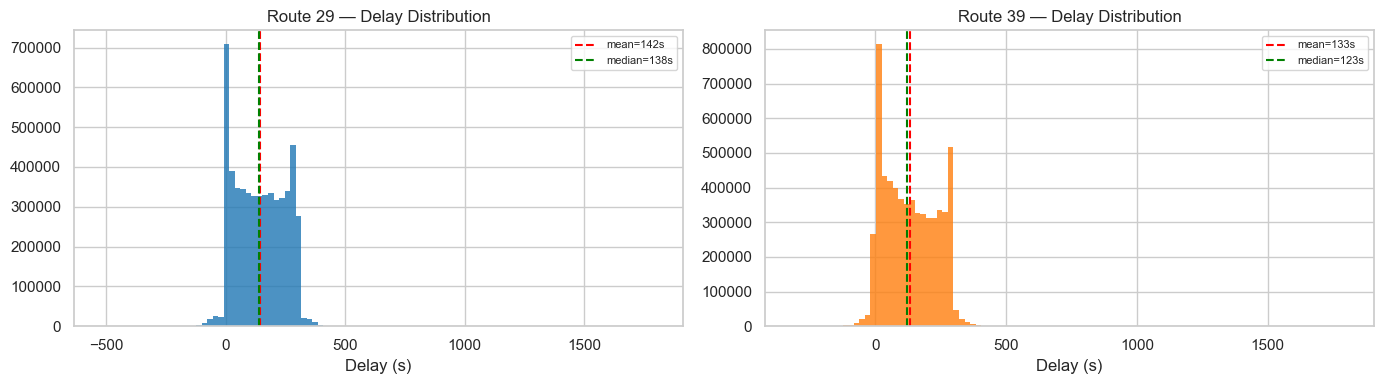

           count        mean         std    min    50%    90%     max
route                                                                
29     5295242.0  141.806917  103.930491 -518.0  138.0  285.0  1799.0
39     6036335.0  132.891097  100.871268 -314.0  123.0  278.0  1800.0


In [43]:
# ── Side-by-side histograms ─────────────────────────────────────────────────
delay_col = 'delay_sec'
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, r in zip(axes, ROUTES):
    df = dfs[r]
    ax.hist(df[delay_col].dropna(), bins=100, color=COLORS[r], edgecolor='none', alpha=0.8)
    ax.set_title(f'Route {r} — Delay Distribution')
    ax.set_xlabel('Delay (s)')
    stats = df[delay_col].describe(percentiles=[.5,.9])
    ax.axvline(stats['mean'], color='red', ls='--', label=f"mean={stats['mean']:.0f}s")
    ax.axvline(stats['50%'], color='green', ls='--', label=f"median={stats['50%']:.0f}s")
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print(df_all.groupby('route')[delay_col].describe(percentiles=[.5,.9]))


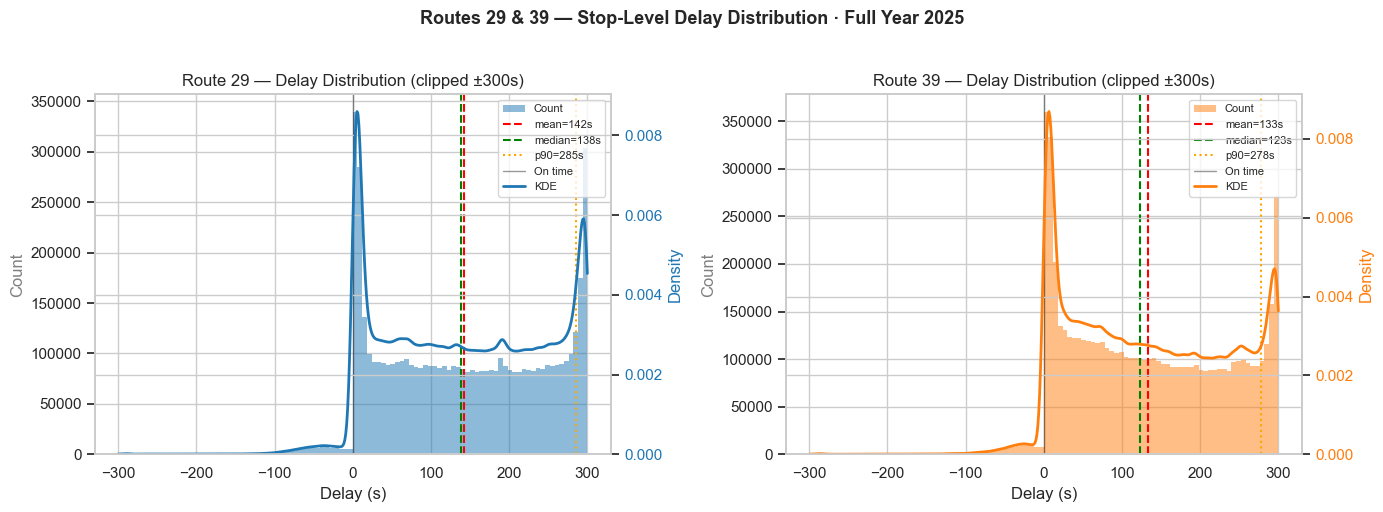

           count   mean    std    min    50%    90%     max
route                                                      
29     5295242.0  141.8  103.9 -518.0  138.0  285.0  1799.0
39     6036335.0  132.9  100.9 -314.0  123.0  278.0  1800.0


In [44]:
# ── Side-by-side histograms with KDE curve ─────────────────────────────────
from scipy.stats import gaussian_kde

delay_col = 'delay_sec'
CLIP_SEC = 300  # clip display to ±5 min for readability

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, r in zip(axes, ROUTES):
    df = dfs[r]
    data = df[delay_col].dropna()
    data_clipped = data.clip(-CLIP_SEC, CLIP_SEC)

    # ── Histogram (left y-axis: counts) ──
    ax.hist(data_clipped, bins=100, color=COLORS[r],
            edgecolor='none', alpha=0.5, label='Count')
    ax.set_xlabel('Delay (s)')
    ax.set_ylabel('Count', color='grey')
    ax.set_title(f'Route {r} — Delay Distribution (clipped ±{CLIP_SEC}s)')

    # ── KDE curve (right y-axis: density) ──
    ax2 = ax.twinx()
    x_range = np.linspace(-CLIP_SEC, CLIP_SEC, 500)
    kde = gaussian_kde(data_clipped, bw_method='scott')
    ax2.plot(x_range, kde(x_range), color=COLORS[r],
             linewidth=2, label='KDE')
    ax2.set_ylabel('Density', color=COLORS[r])
    ax2.tick_params(axis='y', labelcolor=COLORS[r])
    ax2.set_ylim(bottom=0)

    # ── Reference lines ──
    stats = data.describe(percentiles=[.5, .9])
    ax.axvline(stats['mean'],  color='red',   ls='--', lw=1.5,
               label=f"mean={stats['mean']:.0f}s")
    ax.axvline(stats['50%'],   color='green', ls='--', lw=1.5,
               label=f"median={stats['50%']:.0f}s")
    ax.axvline(stats['90%'],   color='orange',ls=':',  lw=1.5,
               label=f"p90={stats['90%']:.0f}s")
    ax.axvline(0,              color='black', ls='-',  lw=1,
               alpha=0.4, label='On time')

    # ── Combined legend ──
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper right')

plt.suptitle('Routes 29 & 39 — Stop-Level Delay Distribution · Full Year 2025',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(df_all.groupby('route')[delay_col].describe(percentiles=[.5, .9]).round(1))

## Comparison 2 — Mean Delay by Time of Day

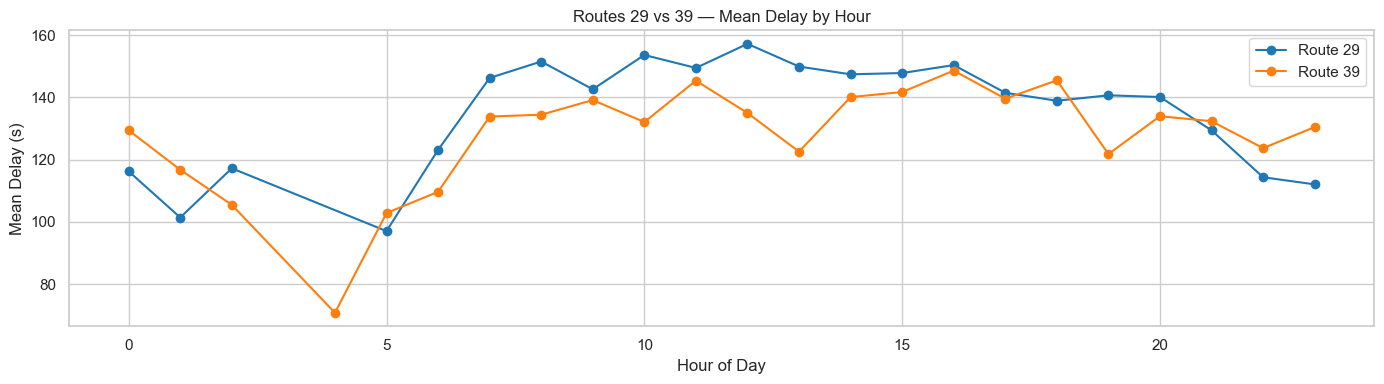

In [45]:
# ── Hour-of-day comparison ─────────────────────────────────────────────────
hourly = df_all.groupby(['route','hour_of_day'])[delay_col].mean().reset_index()
for r, g in hourly.groupby('route'):
    plt.plot(g['hour_of_day'], g[delay_col], marker='o', color=COLORS[r], label=f'Route {r}')
plt.xlabel('Hour of Day'); plt.ylabel('Mean Delay (s)')
plt.title('Routes 29 vs 39 — Mean Delay by Hour')
plt.legend(); plt.tight_layout(); plt.show()
# print("TODO C2: hourly comparison")


## Comparison 3 — Bunching Rate by Route

In [46]:
# ── Bunching comparison ────────────────────────────────────────────────────
for r in ROUTES:
    df = dfs[r]
    if 'scheduled_headway_sec' in df.columns and 'actual_headway_sec' in df.columns:
        bunching_rate = (df['actual_headway_sec'] < 0.5 * df['scheduled_headway_sec']).mean()
        print(f"Route {r} bunching rate: {bunching_rate*100:.1f}%")
# print("TODO C3: bunching comparison")


In [47]:
# ── Join direction from GTFS trips ─────────────────────────────────────────
gtfs_trips = pd.read_csv(
    '../data/raw/gtfs/gtfs_merged_29_39/trips.csv', dtype=str
)[['trip_id', 'direction_id']].drop_duplicates('trip_id')

# Map direction_id to human-readable labels per route
# Route 29 (Dufferin):  0 = Southbound, 1 = Northbound
# Route 39 (Finch East): 0 = Westbound,  1 = Eastbound
dir_label = {
    ('29', '0'): 'Southbound', ('29', '1'): 'Northbound',
    ('39', '0'): 'Westbound',  ('39', '1'): 'Eastbound',
}

df_all = df_all.merge(
    gtfs_trips.rename(columns={'trip_id': 'gtfs_trip_id'}),
    on='gtfs_trip_id', how='left'
)
df_all['direction'] = df_all.apply(
    lambda row: dir_label.get((row['route'], str(row['direction_id'])), 'Unknown'),
    axis=1
)

# Keep dfs in sync
for r in ROUTES:
    dfs[r] = df_all[df_all['route'] == r].copy()

print(df_all.groupby(['route', 'direction']).size())

route  direction 
29     Northbound    2192385
       Southbound    3102857
39     Eastbound     3015428
       Westbound     3020907
dtype: int64


## Comparison 4 — Stop-Level Delay Profiles

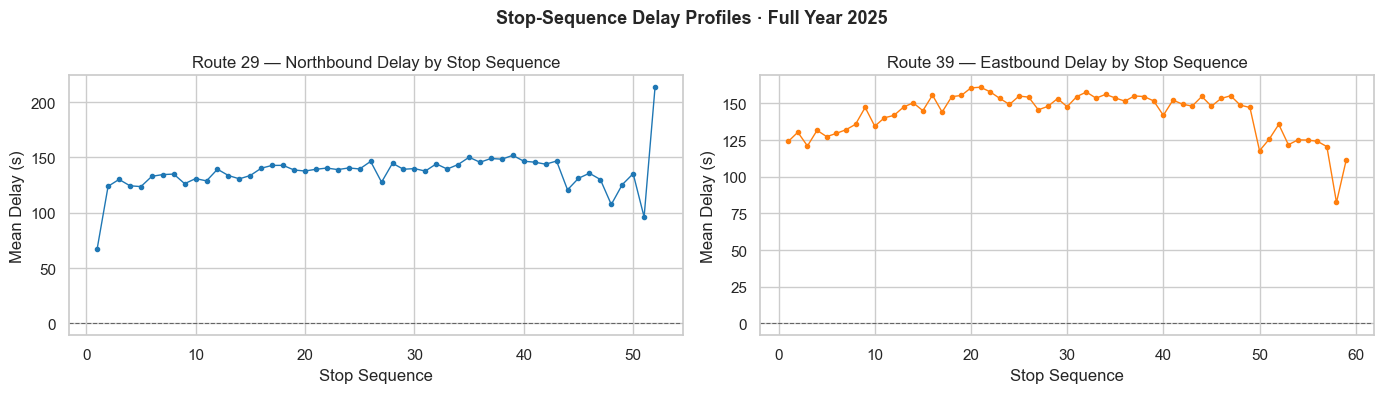

In [48]:
# ── Stop-sequence delay profiles ───────────────────────────────────────────
delay_col = 'delay_sec'

# Direction labels per route for filtering
DIR_LABEL = {'29': 'Northbound', '39': 'Eastbound'}

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, r in zip(axes, ROUTES):
    direction_filter = DIR_LABEL[r]
    nb = dfs[r][dfs[r]['direction'] == direction_filter]
    s  = nb.groupby('stop_sequence')[delay_col].mean()
    ax.plot(s.index, s.values, color=COLORS[r], marker='.', linewidth=1)
    ax.set_title(f'Route {r} — {direction_filter} Delay by Stop Sequence')
    ax.set_xlabel('Stop Sequence')
    ax.set_ylabel('Mean Delay (s)')
    ax.axhline(0, color='black', ls='--', linewidth=0.8, alpha=0.5)

plt.suptitle('Stop-Sequence Delay Profiles · Full Year 2025',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Comparison 5 — Cascading Effect Correlation

In [51]:
# ── Previous-trip-delay correlation (cascading effect) ─────────────────────
delay_col = 'delay_sec'

for r in ROUTES:
    df = dfs[r].copy()

    vt = (df.sort_values(['vehicle', 'timestamp'])
            .groupby(['vehicle', 'gtfs_trip_id'])
            .agg(
                trip_start = ('timestamp',  'min'),
                end_delay  = (delay_col,    'last')
            )
            .reset_index()
            .sort_values(['vehicle', 'trip_start'])
         )

    vt['prev'] = vt.groupby('vehicle')['end_delay'].shift(1)
    corr = vt[['end_delay', 'prev']].corr().iloc[0, 1]
    print(f"Route {r} — cascade corr end_delay[N] vs [N-1]: {corr:.3f}")

Route 29 — cascade corr end_delay[N] vs [N-1]: 0.044
Route 39 — cascade corr end_delay[N] vs [N-1]: 0.052


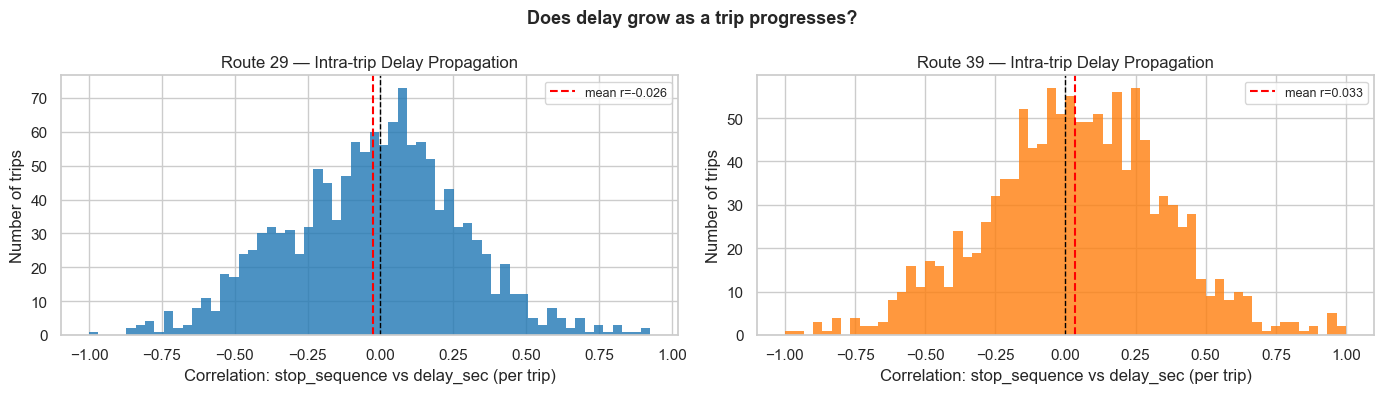

In [53]:
# ── Intra-trip delay propagation: does delay grow along a trip? ────────────
delay_col = 'delay_sec'

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, r in zip(axes, ROUTES):
    df = dfs[r].copy()
    
    # For each trip, compute: correlation between stop_sequence and delay
    # A positive correlation = delay grows as the trip progresses (propagation)
    trip_corrs = (df.groupby('gtfs_trip_id')
                    .apply(lambda g: g['stop_sequence'].corr(g[delay_col]))
                    .dropna())
    
    ax.hist(trip_corrs, bins=60, color=COLORS[r], edgecolor='none', alpha=0.8)
    ax.axvline(0, color='black', ls='--', lw=1)
    ax.axvline(trip_corrs.mean(), color='red', ls='--', lw=1.5,
               label=f'mean r={trip_corrs.mean():.3f}')
    ax.set_xlabel('Correlation: stop_sequence vs delay_sec (per trip)')
    ax.set_ylabel('Number of trips')
    ax.set_title(f'Route {r} — Intra-trip Delay Propagation')
    ax.legend(fontsize=9)

plt.suptitle('Does delay grow as a trip progresses?',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## Summary — Cross-Route Comparison

In [55]:
# ── Summary statistics table ────────────────────────────────────────────────
summary_rows = []
for r in ROUTES:
    df = dfs[r]
    summary_rows.append({
        'route': r,
        'mean_delay_s':  df[delay_col].mean(),
        'median_delay_s': df[delay_col].median(),
        'p90_delay_s':   df[delay_col].quantile(0.9),
        'pct_early':     (df[delay_col] < 0).mean()*100,
        'pct_gt10min':   (df[delay_col] > 600).mean()*100,
    })
summary = pd.DataFrame(summary_rows).set_index('route')
print(summary.round(2))
# print("TODO: fill in summary table")


       mean_delay_s  median_delay_s  p90_delay_s  pct_early  pct_gt10min
route                                                                   
29           141.81           138.0        285.0       1.71         0.03
39           132.89           123.0        278.0       1.61         0.03


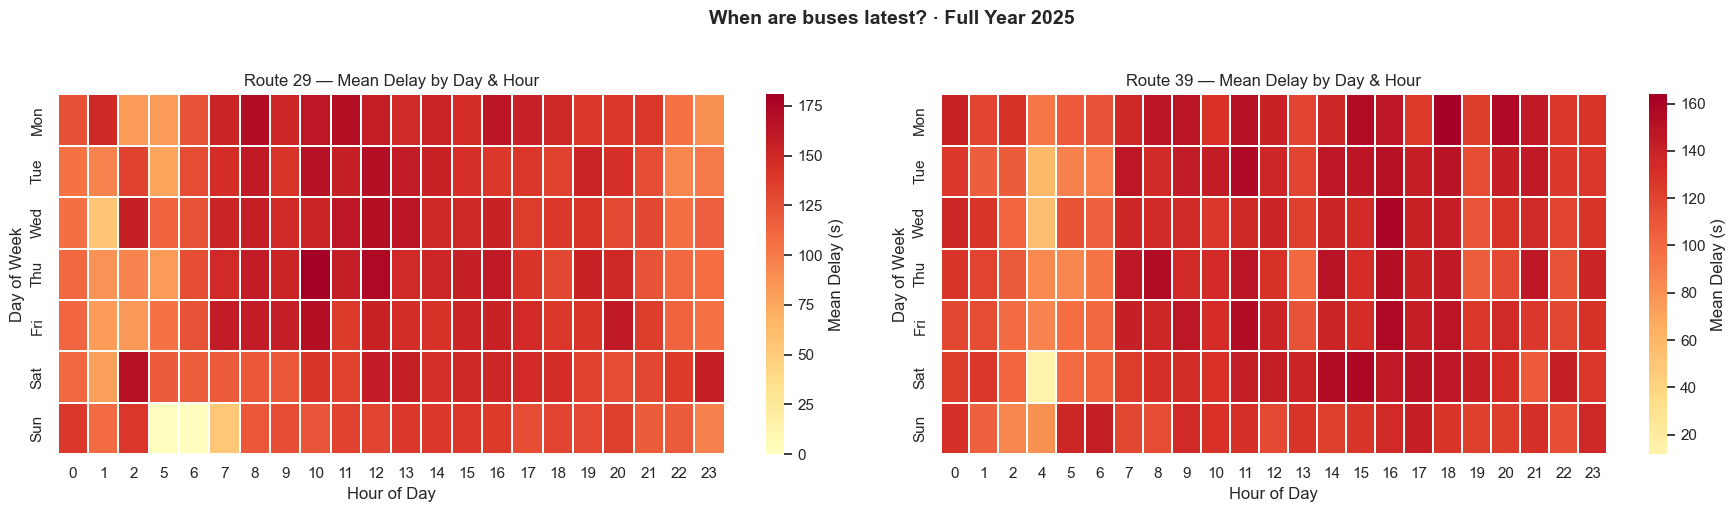

In [56]:
# ── C6: Delay heatmap — day of week × hour of day ──────────────────────────
DAY_LABELS = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for ax, r in zip(axes, ROUTES):
    pivot = (dfs[r]
             .groupby(['day_of_week', 'hour_of_day'])['delay_sec']
             .mean()
             .unstack(fill_value=0))
    pivot.index = [DAY_LABELS[i] for i in pivot.index]

    sns.heatmap(pivot, ax=ax, cmap='RdYlGn_r', center=0,
                linewidths=0.3, linecolor='white',
                cbar_kws={'label': 'Mean Delay (s)'},
                annot=False)
    ax.set_title(f'Route {r} — Mean Delay by Day & Hour', fontsize=12)
    ax.set_xlabel('Hour of Day')
    ax.set_ylabel('Day of Week')

plt.suptitle('When are buses latest? · Full Year 2025',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

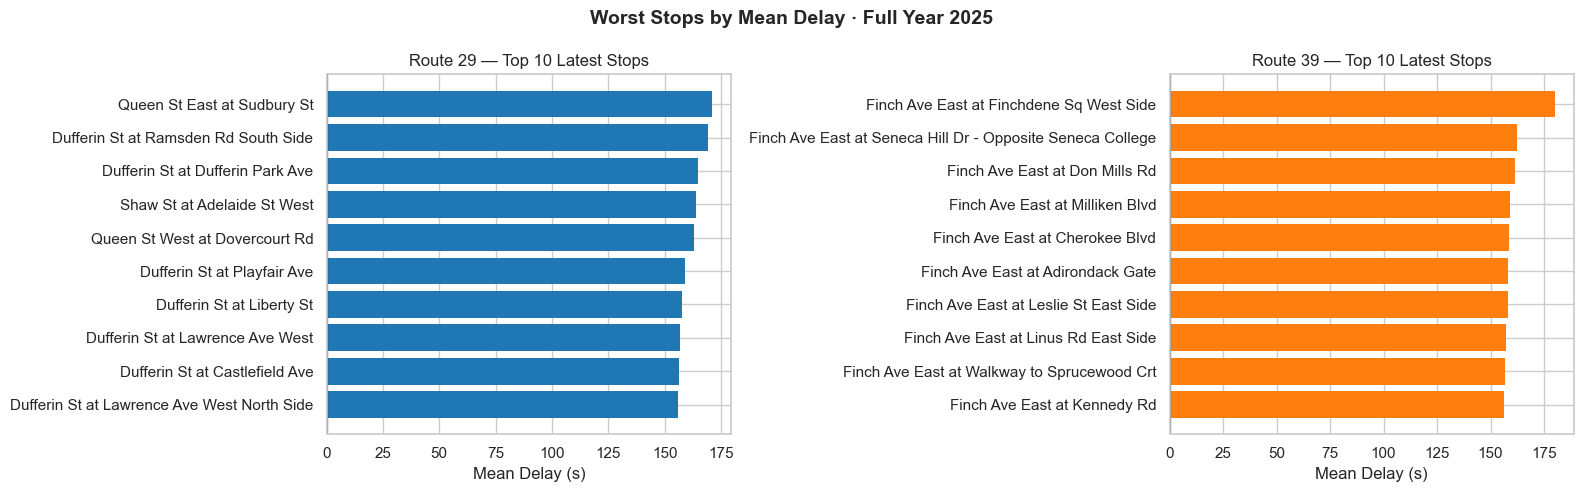

\n── Route 29 top 10 ──
stop_id                                   stop_name  mean_delay  n_obs
  17662                 Queen St East at Sudbury St  170.906429  14652
   1287        Dufferin St at Ramsden Rd South Side  169.358468  79586
   4740            Dufferin St at Dufferin Park Ave  164.673439  62117
    864                 Shaw St at Adelaide St West  163.790021   3848
    799              Queen St West at Dovercourt Rd  162.907711   4811
   1548                 Dufferin St at Playfair Ave  159.011250  72709
   9530                   Dufferin St at Liberty St  157.807862  38618
   1393            Dufferin St at Lawrence Ave West  156.989332  79771
   6062              Dufferin St at Castlefield Ave  156.373609  74693
   5325 Dufferin St at Lawrence Ave West North Side  155.791795  45532
\n── Route 39 top 10 ──
stop_id                                                  stop_name  mean_delay  n_obs
   4430                   Finch Ave East at Finchdene Sq West Side  179.985003   1867

In [57]:
# ── C7: Top 10 worst stops by mean delay ───────────────────────────────────
gtfs_stops = pd.read_csv(
    '../data/raw/gtfs/gtfs_merged_29_39/stops.csv', dtype=str
)[['stop_id','stop_name','stop_lat','stop_lon']].drop_duplicates('stop_id')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, r in zip(axes, ROUTES):
    worst = (dfs[r]
             .groupby('stop_id')['delay_sec']
             .agg(mean_delay='mean', n_obs='count')
             .reset_index()
             .query('n_obs >= 50')          # min observations filter
             .merge(gtfs_stops, on='stop_id', how='left')
             .sort_values('mean_delay', ascending=False)
             .head(10))

    ax.barh(worst['stop_name'].fillna(worst['stop_id']),
            worst['mean_delay'], color=COLORS[r], edgecolor='none')
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel('Mean Delay (s)')
    ax.set_title(f'Route {r} — Top 10 Latest Stops')
    ax.invert_yaxis()

plt.suptitle('Worst Stops by Mean Delay · Full Year 2025',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print table
for r in ROUTES:
    print(f"\\n── Route {r} top 10 ──")
    worst = (dfs[r]
             .groupby('stop_id')['delay_sec']
             .agg(mean_delay='mean', n_obs='count')
             .reset_index().query('n_obs >= 50')
             .merge(gtfs_stops, on='stop_id', how='left')
             .sort_values('mean_delay', ascending=False)
             .head(10)[['stop_id','stop_name','mean_delay','n_obs']])
    print(worst.to_string(index=False))

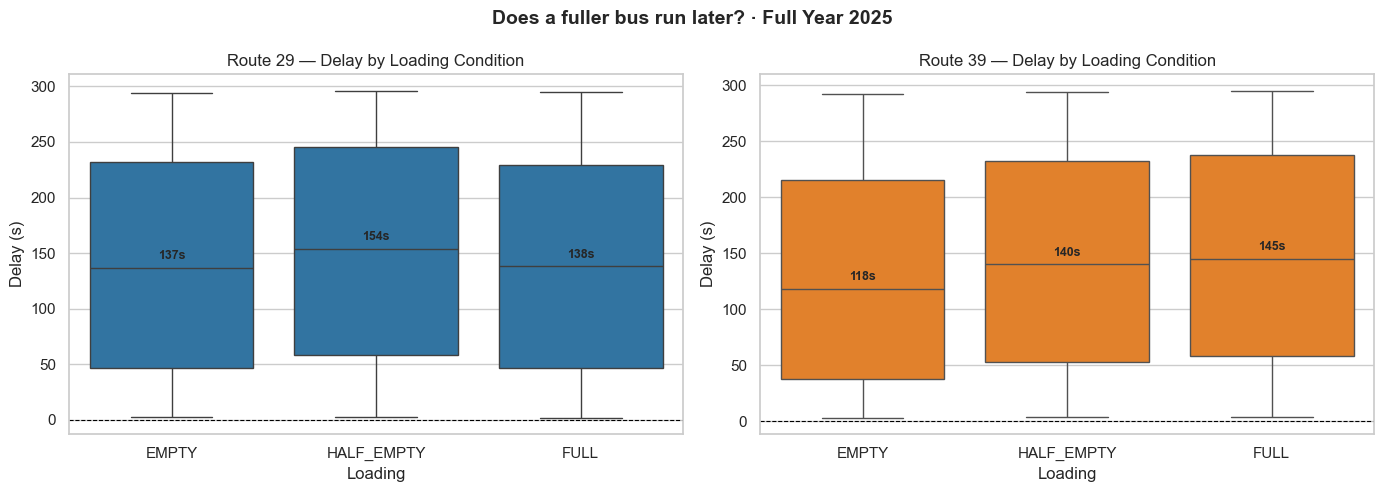

\n── Median delay by loading ──
loading  EMPTY   FULL  HALF_EMPTY
route                            
29       137.0  138.0       154.0
39       118.0  145.0       140.0


In [58]:
# ── C8: Loading condition vs delay ─────────────────────────────────────────
LOADING_ORDER = ['EMPTY', 'HALF_EMPTY', 'FULL']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, r in zip(axes, ROUTES):
    data = dfs[r][dfs[r]['loading'].isin(LOADING_ORDER)].copy()
    data['loading'] = pd.Categorical(data['loading'],
                                     categories=LOADING_ORDER, ordered=True)

    sns.boxplot(data=data, x='loading', y='delay_sec',
                order=LOADING_ORDER, ax=ax,
                color=COLORS[r], showfliers=False,
                whis=[5, 95])
    ax.axhline(0, color='black', ls='--', lw=0.8)
    ax.set_title(f'Route {r} — Delay by Loading Condition')
    ax.set_xlabel('Loading')
    ax.set_ylabel('Delay (s)')

    # Annotate with median values
    medians = data.groupby('loading', observed=True)['delay_sec'].median()
    for i, cat in enumerate(LOADING_ORDER):
        if cat in medians:
            ax.text(i, medians[cat] + 5, f'{medians[cat]:.0f}s',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Does a fuller bus run later? · Full Year 2025',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\\n── Median delay by loading ──")
print(df_all.groupby(['route','loading'])['delay_sec']
      .median().unstack().round(1).to_string())

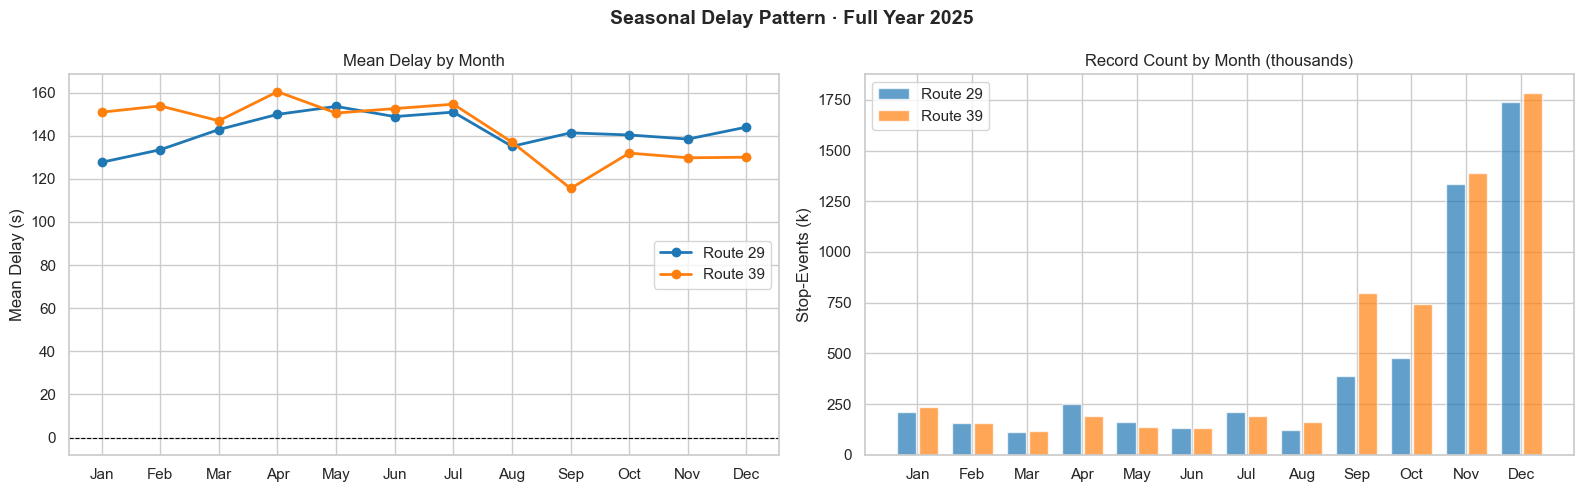

In [59]:
# ── C9: Monthly delay trend ────────────────────────────────────────────────
df_all['month'] = pd.to_datetime(df_all['date']).dt.month
MONTH_LABELS = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

monthly = (df_all.groupby(['route','month'])['delay_sec']
           .agg(mean_delay='mean', median_delay='median', n_obs='count')
           .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax in axes:
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(MONTH_LABELS)

ax1, ax2 = axes
for r in ROUTES:
    g = monthly[monthly['route'] == r]
    ax1.plot(g['month'], g['mean_delay'], marker='o',
             color=COLORS[r], label=f'Route {r}', linewidth=2)
    ax2.bar(g['month'] + (0.2 if r == '39' else -0.2),
            g['n_obs'] / 1000, width=0.35,
            color=COLORS[r], alpha=0.7, label=f'Route {r}')

ax1.axhline(0, color='black', ls='--', lw=0.8)
ax1.set_title('Mean Delay by Month')
ax1.set_ylabel('Mean Delay (s)')
ax1.legend()

ax2.set_title('Record Count by Month (thousands)')
ax2.set_ylabel('Stop-Events (k)')
ax2.legend()

plt.suptitle('Seasonal Delay Pattern · Full Year 2025',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

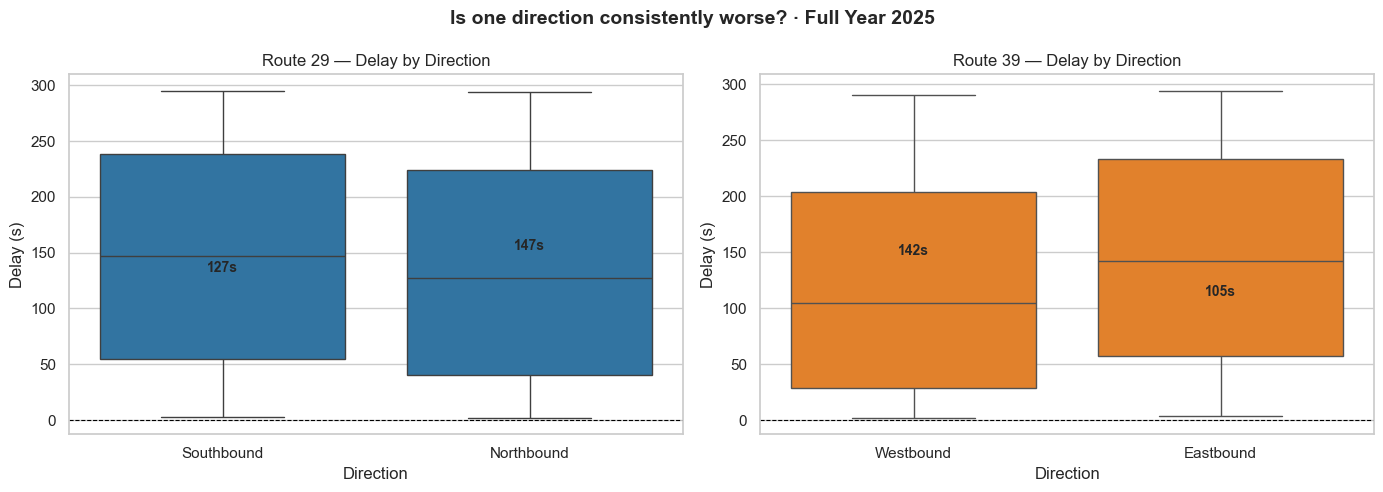

\n── Median delay by route & direction ──
route  direction 
29     Northbound    127.0
       Southbound    147.0
39     Eastbound     142.0
       Westbound     105.0


In [60]:
# ── C10: Delay by direction ────────────────────────────────────────────────
DIR_LABELS = {
    '29': {'0': 'Southbound', '1': 'Northbound'},
    '39': {'0': 'Westbound',  '1': 'Eastbound'},
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, r in zip(axes, ROUTES):
    df = dfs[r][dfs[r]['direction_id'].notna()].copy()
    df['dir_label'] = df['direction_id'].map(DIR_LABELS[r])

    sns.boxplot(data=df, x='dir_label', y='delay_sec',
                ax=ax, color=COLORS[r], showfliers=False, whis=[5, 95])
    ax.axhline(0, color='black', ls='--', lw=0.8)
    ax.set_title(f'Route {r} — Delay by Direction')
    ax.set_xlabel('Direction')
    ax.set_ylabel('Delay (s)')

    medians = df.groupby('dir_label')['delay_sec'].median()
    for i, (label, val) in enumerate(medians.items()):
        ax.text(i, val + 3, f'{val:.0f}s',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Is one direction consistently worse? · Full Year 2025',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\\n── Median delay by route & direction ──")
print(df_all.groupby(['route','direction'])['delay_sec']
      .median().round(1).to_string())

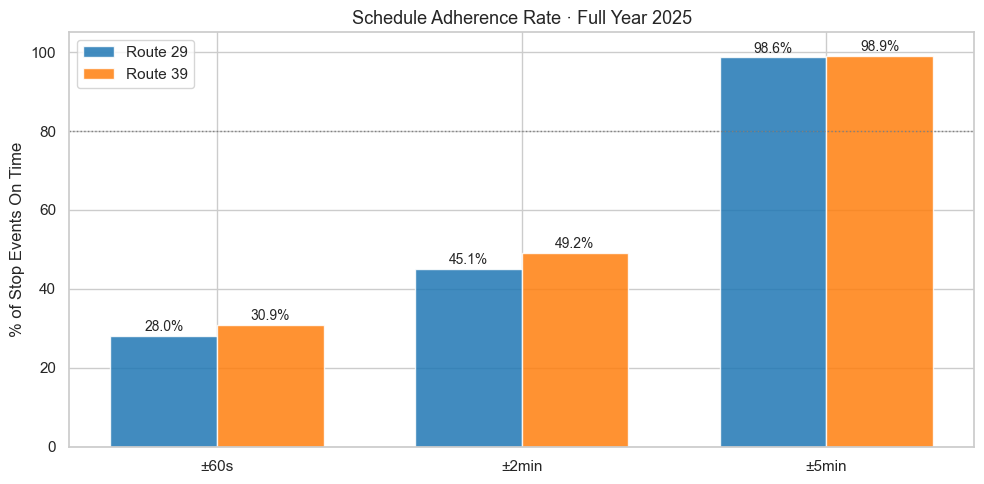

\n── Schedule adherence rates ──
\nRoute 29:
  ±60s: 28.0%
  ±2min: 45.1%
  ±5min: 98.6%
\nRoute 39:
  ±60s: 30.9%
  ±2min: 49.2%
  ±5min: 98.9%


In [61]:
# ── C11: Schedule adherence KPIs ───────────────────────────────────────────
thresholds = {'±60s': 60, '±2min': 120, '±5min': 300}

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(thresholds))
width = 0.35

for i, r in enumerate(ROUTES):
    rates = [
        (dfs[r]['delay_sec'].abs() <= v).mean() * 100
        for v in thresholds.values()
    ]
    bars = ax.bar(x + i * width, rates, width,
                  label=f'Route {r}', color=COLORS[r], alpha=0.85)
    for bar, rate in zip(bars, rates):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                f'{rate:.1f}%', ha='center', va='bottom', fontsize=10)

ax.set_xticks(x + width / 2)
ax.set_xticklabels(thresholds.keys())
ax.set_ylabel('% of Stop Events On Time')
ax.set_ylim(0, 105)
ax.set_title('Schedule Adherence Rate · Full Year 2025', fontsize=13)
ax.legend()
ax.axhline(80, color='grey', ls=':', lw=1, label='80% target')
plt.tight_layout()
plt.show()

print("\\n── Schedule adherence rates ──")
for r in ROUTES:
    print(f"\\nRoute {r}:")
    for label, v in thresholds.items():
        pct = (dfs[r]['delay_sec'].abs() <= v).mean() * 100
        print(f"  {label}: {pct:.1f}%")

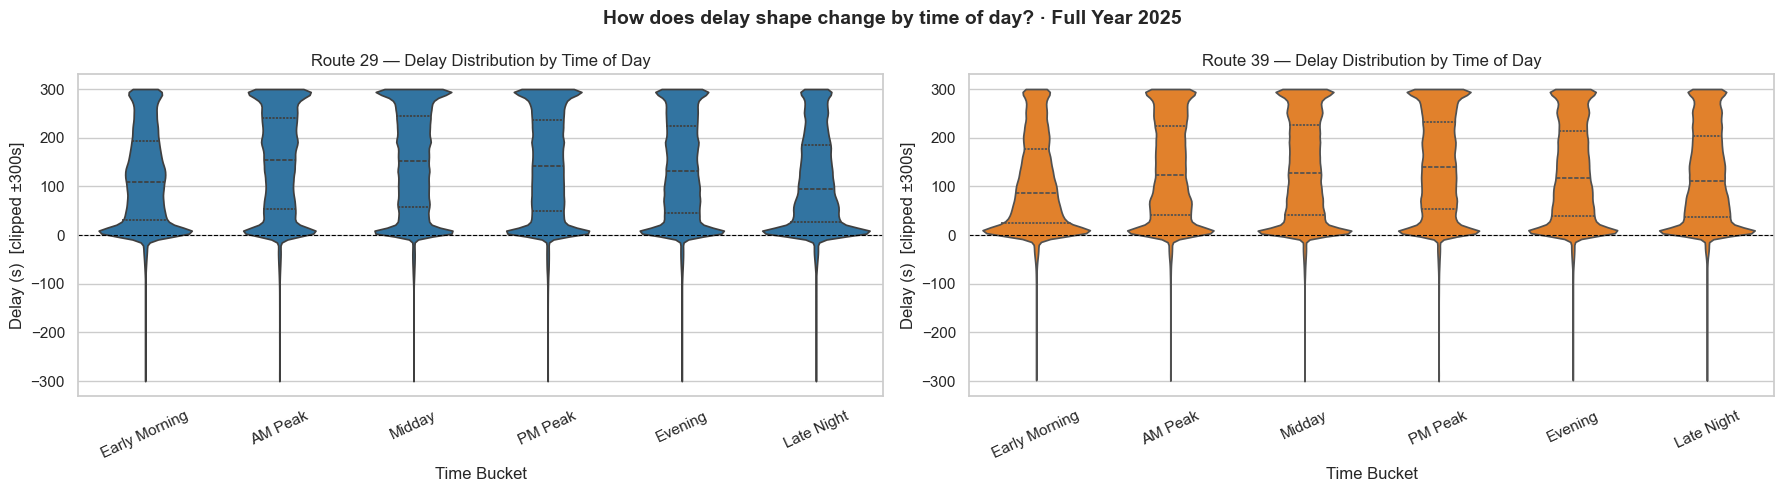

\n── Median delay by time bucket ──
time_bucket  AM Peak  Early Morning  Evening  Late Night  Midday  PM Peak
route                                                                    
29             154.0          109.0    131.0        95.0   153.0    142.0
39             123.0           86.0    117.0       111.0   128.0    140.0


In [62]:
# ── C12: Delay distribution by time bucket ─────────────────────────────────
BUCKET_ORDER = ['Early Morning','AM Peak','Midday',
                'PM Peak','Evening','Late Night']

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for ax, r in zip(axes, ROUTES):
    data = dfs[r][dfs[r]['time_bucket'].isin(BUCKET_ORDER)].copy()
    data['time_bucket'] = pd.Categorical(data['time_bucket'],
                                         categories=BUCKET_ORDER, ordered=True)
    data_clipped = data.copy()
    data_clipped['delay_sec'] = data_clipped['delay_sec'].clip(-300, 300)

    sns.violinplot(data=data_clipped, x='time_bucket', y='delay_sec',
                   order=BUCKET_ORDER, ax=ax, color=COLORS[r],
                   inner='quartile', cut=0)
    ax.axhline(0, color='black', ls='--', lw=0.8)
    ax.set_title(f'Route {r} — Delay Distribution by Time of Day')
    ax.set_xlabel('Time Bucket')
    ax.set_ylabel('Delay (s)  [clipped ±300s]')
    ax.tick_params(axis='x', rotation=25)

plt.suptitle('How does delay shape change by time of day? · Full Year 2025',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\\n── Median delay by time bucket ──")
print(df_all.groupby(['route','time_bucket'])['delay_sec']
      .median().unstack().round(1).to_string())

In [66]:
# ── C13a: Compute actual headways at each stop ─────────────────────────────

def compute_headways(df):
    df = df.copy()

    # Sort by actual arrival within each (date, route, direction, stop) group
    df = df.sort_values(['date', 'route', 'direction_id',
                         'stop_id', 'actual_time_sec'])

    # Actual headway = gap between consecutive vehicles at same stop
    df['actual_hw_sec'] = (
        df.groupby(['date', 'route', 'direction_id', 'stop_id'],
                   observed=True)['actual_time_sec']
        .diff()
    )

    # Scheduled headway = gap between consecutive scheduled arrivals
    df_sched = df.sort_values(['date', 'route', 'direction_id',
                               'stop_id', 'sched_arrival_sec'])
    df_sched['sched_hw_sec'] = (
        df_sched.groupby(['date', 'route', 'direction_id', 'stop_id'],
                         observed=True)['sched_arrival_sec']
        .diff()
    )
    df['sched_hw_sec'] = df_sched['sched_hw_sec']

    # Drop first vehicle per stop (no preceding vehicle)
    df = df.dropna(subset=['actual_hw_sec', 'sched_hw_sec'])

    # Sanity filter: headways between 30s and 90 min
    df = df[(df['actual_hw_sec'] > 30) & (df['actual_hw_sec'] < 5400)]
    df = df[(df['sched_hw_sec']  > 30) & (df['sched_hw_sec']  < 5400)]

    # Bunching / gapping flags
    df['bunching'] = df['actual_hw_sec'] < 0.5 * df['sched_hw_sec']
    df['gapping']  = df['actual_hw_sec'] > 2.0 * df['sched_hw_sec']
    df['hw_ratio'] = df['actual_hw_sec'] / df['sched_hw_sec']

    return df


# Select only needed columns — include time_bucket and hour_of_day
hw_input = df_all[[
    'date', 'route', 'direction_id', 'stop_id',
    'actual_time_sec', 'sched_arrival_sec',
    'hour_of_day', 'day_of_week', 'is_weekday', 'time_bucket'
]].copy()

print("Computing headways...")
hw_df = compute_headways(hw_input)

print(f"Headway records: {len(hw_df):,}")
print(f"\\n── Bunching & gapping rates ──")
for r in ROUTES:
    g = hw_df[hw_df['route'] == r]
    print(f"\\nRoute {r}:")
    print(f"  Bunching rate (actual < 0.5×sched): {g['bunching'].mean()*100:.1f}%")
    print(f"  Gapping  rate (actual > 2.0×sched): {g['gapping'].mean()*100:.1f}%")
    print(f"  Median actual headway:  {g['actual_hw_sec'].median()/60:.1f} min")
    print(f"  Median sched  headway:  {g['sched_hw_sec'].median()/60:.1f} min")

Computing headways...
Headway records: 605,996
\n── Bunching & gapping rates ──
\nRoute 29:
  Bunching rate (actual < 0.5×sched): 3.8%
  Gapping  rate (actual > 2.0×sched): 0.9%
  Median actual headway:  16.6 min
  Median sched  headway:  16.0 min
\nRoute 39:
  Bunching rate (actual < 0.5×sched): 1.3%
  Gapping  rate (actual > 2.0×sched): 0.5%
  Median actual headway:  20.1 min
  Median sched  headway:  19.0 min


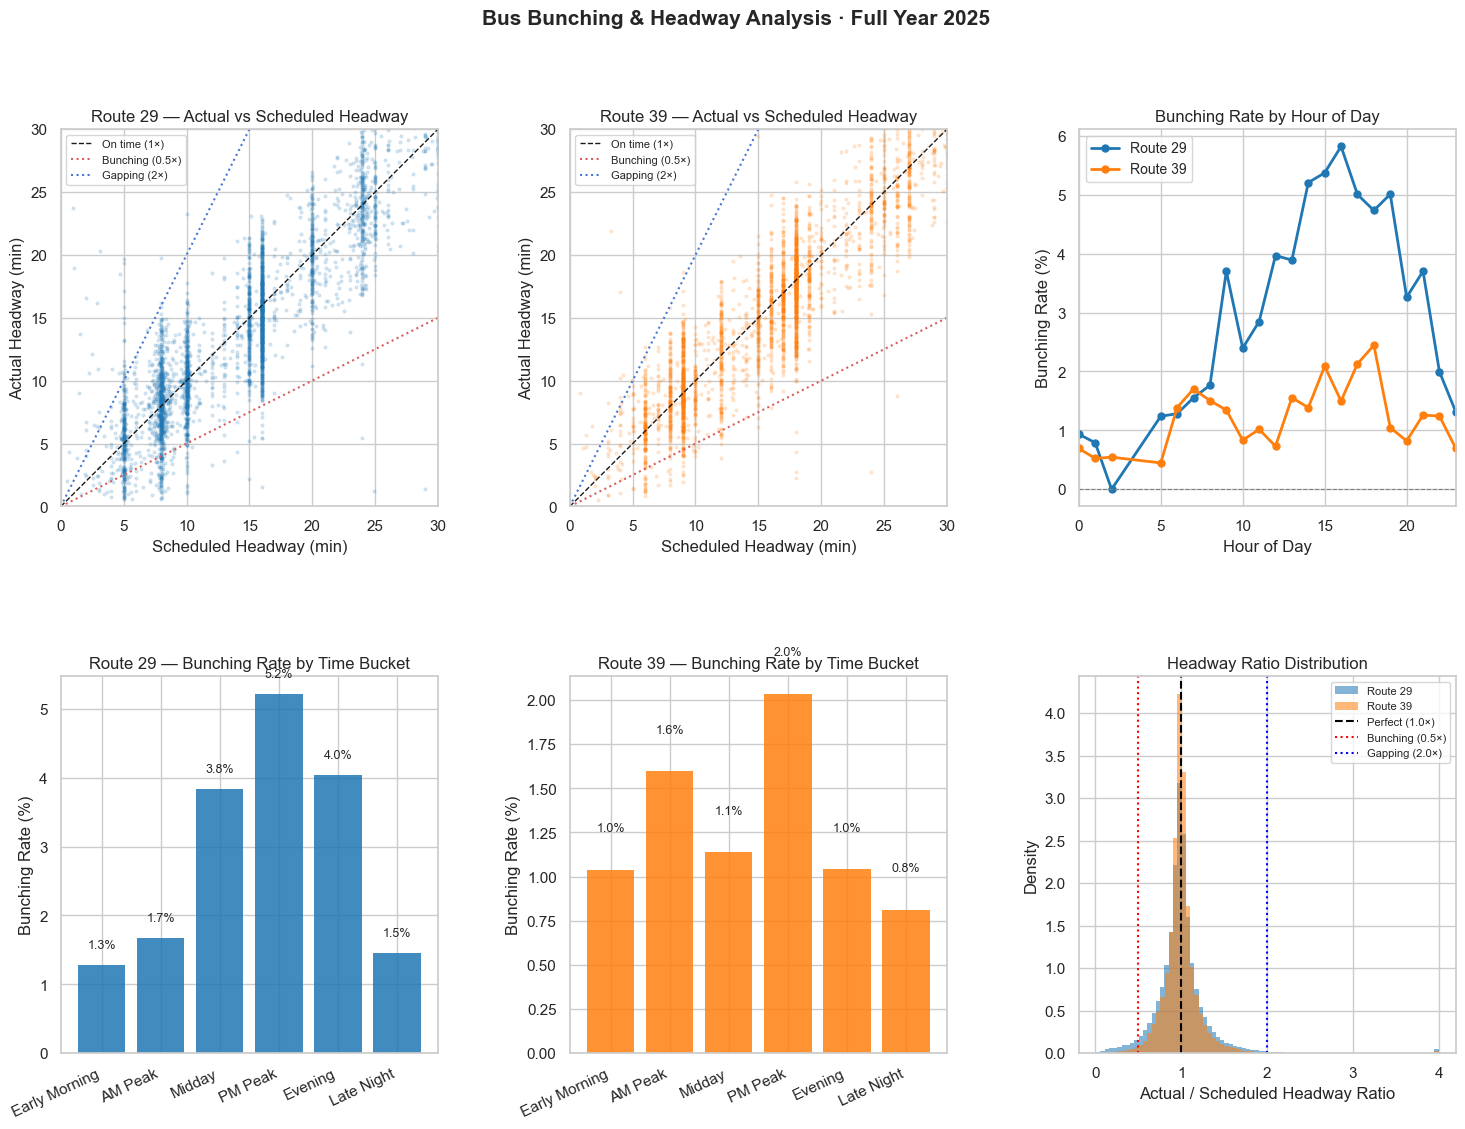

\n── Schedule adherence by time bucket ──
\nRoute 29:
              bunching_pct gapping_pct median_hw_min   n_obs
time_bucket                                                 
Early Morning         1.3%        0.1%          15.1    8425
AM Peak               1.7%        0.2%          18.0   24266
Midday                3.8%        0.9%          16.9  104994
PM Peak               5.2%        1.5%          14.8   78788
Evening               4.0%        0.9%          16.8   52621
Late Night            1.5%        0.2%          19.4   26461
\nRoute 39:
              bunching_pct gapping_pct median_hw_min   n_obs
time_bucket                                                 
Early Morning         1.0%        0.4%          17.0   10795
AM Peak               1.6%        0.7%          19.1   26696
Midday                1.1%        0.5%          20.5  100915
PM Peak               2.0%        0.7%          18.5   64127
Evening               1.0%        0.3%          20.9   45065
Late Night         

In [67]:
# ── C13b: Bunching analysis plots ──────────────────────────────────────────
import matplotlib.gridspec as gridspec

BUCKET_ORDER = ['Early Morning', 'AM Peak', 'Midday',
                'PM Peak', 'Evening', 'Late Night']

fig = plt.figure(figsize=(18, 12))
fig.suptitle('Bus Bunching & Headway Analysis · Full Year 2025',
             fontsize=15, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# We'll build ax2 once across the loop (shared between both routes)
ax2 = fig.add_subplot(gs[0, 2])

for col, r in enumerate(ROUTES):
    g = hw_df[hw_df['route'] == r].copy()

    # ── Plot 1: Actual vs Scheduled headway scatter ──────────────────────
    ax1 = fig.add_subplot(gs[0, col])
    sample = g.sample(min(5000, len(g)), random_state=42)
    lim = min(30, max(sample['sched_hw_sec'].max(),
                      sample['actual_hw_sec'].max()) / 60)

    ax1.scatter(sample['sched_hw_sec'] / 60,
                sample['actual_hw_sec'] / 60,
                alpha=0.15, s=4, color=COLORS[r])
    ax1.plot([0, lim], [0, lim],         'k--', lw=1,   label='On time (1×)')
    ax1.plot([0, lim], [0, lim * 0.5],   'r:',  lw=1.5, label='Bunching (0.5×)')
    ax1.plot([0, lim], [0, lim * 2.0],   'b:',  lw=1.5, label='Gapping (2×)')
    ax1.set_xlabel('Scheduled Headway (min)')
    ax1.set_ylabel('Actual Headway (min)')
    ax1.set_title(f'Route {r} — Actual vs Scheduled Headway')
    ax1.set_xlim(0, lim)
    ax1.set_ylim(0, lim)
    ax1.legend(fontsize=8)

    # ── Plot 2: Bunching rate by hour (shared axis, both routes) ─────────
    hourly_bunch = (g.groupby('hour_of_day')['bunching']
                     .mean()
                     .multiply(100))
    ax2.plot(hourly_bunch.index, hourly_bunch.values,
             marker='o', color=COLORS[r],
             label=f'Route {r}', linewidth=2, markersize=5)

    # ── Plot 3: Bunching rate by time bucket ─────────────────────────────
    ax3 = fig.add_subplot(gs[1, col])

    bucket_bunch = (g[g['time_bucket'].isin(BUCKET_ORDER)]
                    .groupby('time_bucket', observed=False)['bunching']
                    .mean()
                    .multiply(100)
                    .reindex(BUCKET_ORDER)
                    .fillna(0))

    bars = ax3.bar(range(len(BUCKET_ORDER)), bucket_bunch.values,
                   color=COLORS[r], alpha=0.85, edgecolor='none')
    ax3.set_xticks(range(len(BUCKET_ORDER)))
    ax3.set_xticklabels(BUCKET_ORDER, rotation=25, ha='right')
    ax3.set_title(f'Route {r} — Bunching Rate by Time Bucket')
    ax3.set_ylabel('Bunching Rate (%)')
    for i, v in enumerate(bucket_bunch.values):
        ax3.text(i, v + 0.2, f'{v:.1f}%',
                 ha='center', va='bottom', fontsize=9)

# Finish Plot 2 formatting
ax2.set_xlabel('Hour of Day')
ax2.set_ylabel('Bunching Rate (%)')
ax2.set_title('Bunching Rate by Hour of Day')
ax2.set_xlim(0, 23)
ax2.axhline(0, color='grey', ls='--', lw=0.8)
ax2.legend(fontsize=10)

# ── Plot 4: Headway ratio distribution (bottom right) ───────────────────
ax4 = fig.add_subplot(gs[1, 2])
for r in ROUTES:
    g = hw_df[hw_df['route'] == r]
    clipped = g['hw_ratio'].clip(0, 4)
    ax4.hist(clipped, bins=80, alpha=0.55,
             color=COLORS[r], label=f'Route {r}',
             edgecolor='none', density=True)
ax4.axvline(1.0, color='black', ls='--', lw=1.5, label='Perfect (1.0×)')
ax4.axvline(0.5, color='red',   ls=':',  lw=1.5, label='Bunching (0.5×)')
ax4.axvline(2.0, color='blue',  ls=':',  lw=1.5, label='Gapping (2.0×)')
ax4.set_xlabel('Actual / Scheduled Headway Ratio')
ax4.set_ylabel('Density')
ax4.set_title('Headway Ratio Distribution')
ax4.legend(fontsize=8)

plt.show()

# ── Summary table ────────────────────────────────────────────────────────
print("\\n── Schedule adherence by time bucket ──")
for r in ROUTES:
    g = hw_df[hw_df['route'] == r]
    print(f"\\nRoute {r}:")
    tbl = (g[g['time_bucket'].isin(BUCKET_ORDER)]
           .groupby('time_bucket', observed=False)
           .agg(
               bunching_pct  = ('bunching', lambda x: f"{x.mean()*100:.1f}%"),
               gapping_pct   = ('gapping',  lambda x: f"{x.mean()*100:.1f}%"),
               median_hw_min = ('actual_hw_sec', lambda x: f"{x.median()/60:.1f}"),
               n_obs         = ('bunching', 'count')
           )
           .reindex(BUCKET_ORDER))
    print(tbl.to_string())

# EDA Key Insights — TTC Routes 29 & 39 (2025)

## 1. Delays are chronic, not extreme
Both routes run late virtually 100% of the time — median delay is **138s (Rt 29)** and **123s (Rt 39)**.
The 90th percentile is ~ **280s (~4.7 min)**, and only 0.03% of stop events exceed 10 minutes.
This means the problem is systemic lateness, not occasional catastrophic failures.
Buses are never really "on time" the schedule is structurally optimistic.

## 2. Schedule adherence is very poor at fine tolerance, acceptable at coarse
- Within ±60s: only **28% (Rt 29)** and **31% (Rt 39)**
- Within ±2min: **45% / 49%**
- Within ±5min: **98.6% / 98.9%**

The ±5min window is almost meaningless as a performance metric for these routes.
If TTC uses ±5min as its KPI, it masks the real operational problem.

## 3. Peak delay pattern differs by route
- Route 29: **AM Peak** is worst (154s median) — a north–south Dufferin St route hit hard by morning congestion
- Route 39: **PM Peak** is worst (140s median) — an east–west Finch Ave route more affected by afternoon traffic

Both routes see Late Night as the best-performing window (95s and 111s respectively).

## 4. Direction asymmetry is significant and route-specific
- Route 29 Southbound (+147s) is consistently **20s worse** than Northbound (127s)
- Route 39 Eastbound (142s) is **37s worse** than Westbound (105s) — the largest asymmetry in the dataset

Westbound Finch is nearly half a bucket better than Eastbound. This strongly suggests direction should be a model feature.

## 5. Loading has almost no effect — except HALF_EMPTY is the worst
Counterintuitively, **FULL buses are not the most delayed**:
- Rt 29: EMPTY=137s, FULL=138s, HALF_EMPTY=154s
- Rt 39: EMPTY=118s, FULL=145s, HALF_EMPTY=140s

HALF_EMPTY buses are consistently the slowest. This likely reflects mid-route stops with frequent boarding/alighting rather than crush loading at terminals.

## 6. Delay does NOT propagate within a trip (intra-trip)
Mean within-trip correlation between stop sequence and delay is **r = −0.026 (Rt 29)** and **r = +0.033 (Rt 39)** — effectively zero.
Delays do not systematically accumulate stop-by-stop within a single run. This contradicts the naive assumption that "buses fall further behind as the trip goes on."

## 7. Delay does NOT propagate between trips (inter-trip cascade)
Inter-trip cascade correlation (end-of-trip delay predicting next trip's delay, same vehicle) is **0.044 (Rt 29)** and **0.052 (Rt 39)** — near zero.
The ripple-effect / delay inheritance that Shalaby & Farhan found on higher-frequency routes is absent here. Each trip essentially "resets." This is important: **prior trip delay is not a useful predictor** for these routes.

## 8. Bunching is a Route 29 problem, not Route 39
- Route 29 bunching rate: **3.8%** overall, peaking at **5.2% during PM Peak**
- Route 39 bunching rate: **1.3%** overall, peaking at **2.0% during PM Peak**

Route 29 bunches at 3× the rate of Route 39. Gapping is rare on both (<1.5%), meaning the service failure mode is buses clumping, not large gaps.
Route 29's PM Peak bunching (5.2%) combined with its longer median actual headway (16.6 min vs scheduled 16.0 min) indicates real-time schedule slippage in the afternoon.

## 9. Delay is geographically concentrated, a handful of stops dominate
Both routes show a clear Pareto pattern:
- **Rt 29**: 8 of top 10 worst stops are on **Dufferin St** between Lawrence Ave and Liberty St. The Dufferin corridor is structurally slow.
- **Rt 39**: All top 10 worst stops are on **Finch Ave East**, clustered between **Don Mills Rd and Milliken Blvd** (the eastern half). The western portion of Route 39 is significantly better-behaved.

Stop ID is likely the single most predictive feature in any model trained on this data.